We downloaded the datas from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=download respecting the exact criterias mentionned in the main core of the paper and appendiwx b, as you can see in our api request

In [2]:
%pip install cdsapi

  Using cached cdsapi-0.7.7-py2.py3-none-any.whl.metadata (3.1 kB)
  Using cached ecmwf_datastores_client-0.5.1-py3-none-any.whl.metadata (21 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached multiurl-0.3.7-py3-none-any.whl.metadata (2.8 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached cdsapi-0.7.7-py2.py3-none-any.whl (12 kB)
Using cached ecmwf_datastores_client-0.5.1-py3-none-any.whl (29 kB)
Using cached multiurl-0.3.7-py3-none-any.whl (21 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)

   ---------------------------------------- 0/5 [pytz]
   ---------------------------------------- 0/5 [pytz]
   ------------------------ --------------- 3/5 [ecmwf-datastores-client]
   ---------------------------------------- 5/5 [cdsapi]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cdsapi

dataset = "reanalysis-era5-pressure-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": ["vorticity"],
    "year": ["1980"],
    "month": ["07"],
    "day": ["15"],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "pressure_level": ["500"],
    "data_format": "netcdf",
    "download_format": "unarchived"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download("era5_cds_test_3.nc")


2026-06-09 11:04:38,060 INFO Request ID is 35ca0d5e-5d00-4338-8dfe-af2a19c35493
2026-06-09 11:04:38,173 INFO status has been updated to accepted
2026-06-09 11:07:30,353 INFO status has been updated to successful


'era5_cds_test_3.nc'

As you can see, the paper bullshited us from the beginning. They told us that we normally have 574, 1148 for longitutde and latitude, but we have 721,1440. I verfied on the website there is no other way to download and they do not explain anything about this in the paper. After, they explained in the paper that they made a reduce of 13 to have 45 * 89. Fortunately, if we divide 721 and 1440 by 16, we approximatively 45 * 89 

In [4]:
%pip install xarray netCDF4 h5netcdf 

  Using cached xarray-2026.4.0-py3-none-any.whl.metadata (12 kB)
  Using cached netcdf4-1.7.4-cp311-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached h5netcdf-1.8.1-py3-none-any.whl.metadata (15 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached xarray-2026.4.0-py3-none-any.whl (1.4 MB)
Using cached netcdf4-1.7.4-cp311-abi3-win_amd64.whl (21.3 MB)
Using cached h5netcdf-1.8.1-py3-none-any.whl (62 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------------------------ --------------- 7.6/12.3 MB 42.0 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 39.4 MB/s  0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------  9.7/9.8 MB 52.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 46.1 MB/s  0:00:00
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/7 [tzdata]
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import xarray as xr

#we open the dataset using xarray to explore its structure and contents
path = "aa98ad1a79ebfb940dc8aea9a3dde72a.nc"
ds = xr.open_dataset(path)


#The dataset contains the following variables and coordinates
print("variables:", list(ds.data_vars))
print("coords:", list(ds.coords))



#We explore the variable relative vorticity to understand the structure of the dataset'''
print("vo shape:", ds["vo"].shape)

'''We explore the coordinate time count to understand the structure of the dataset'''
#print("number", "variables:", (ds["number"])) is unuseful to check

#We explore the coordinate number to understand the structure of the dataset'''
print("time count:", len(ds["valid_time"]))

#We explore the coordinate pressure level to understand the structure of the dataset'''
print("pressure:", ds["pressure_level"].values)

#We explore the coordinate latitude and longitude to understand the structure of the dataset'''
print("lat count:", len(ds["latitude"]))
print("lon count:", len(ds["longitude"]))

#We explore the coordinate time to understand the structure of the dataset'''
print("first time:", ds["valid_time"].values[0])
print("last time:", ds["valid_time"].values[-1])

#We explore the coordinate latitude and longitude to understand the dimensionality of the dataset'''
print("lat first/last:", ds["latitude"].values[0], ds["latitude"].values[-1])
print("lon first/last:", ds["longitude"].values[0], ds["longitude"].values[-1])

variables: ['vo']
coords: ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
vo shape: (24, 1, 721, 1440)
time count: 24
pressure: [500.]
lat count: 721
lon count: 1440
first time: 1980-07-15T00:00:00.000000000
last time: 1980-07-15T23:00:00.000000000
lat first/last: 90.0 -90.0
lon first/last: 0.0 359.75


Because those "genius" used told in the paper wrong format of datas and had 721, 1440 instead of 574, 1148 and did they dowsampling by 13 to have 45  * 89 we will adapt taking into the data 720 and 1424 instead of the 721 1440 that we downloaded to have the abilty to divide by 16 and go exactly on 45 * 89 so yeah we lose 1 point on 721 and 16 points on 1440 hopefully it's very few and more importantly I documented it here

In [6]:
'''
#I squeezed the data cause we only asked for 1 level of pression and it would make no sense to downsample this dimension
real_vorticity = ds["vo"].squeeze().values

#I just want to check the shape of the data before downsampling
lat = ds["latitude"].values
lon = ds["longitude"].values
time = ds["valid_time"].values

#So I print it haha
print("Before downsample")
print("real_vorticity:", real_vorticity.shape)
print("lat:", lat.shape)
print("lon:", lon.shape)
print("time:", time.shape)

#Now I downsample the data by taking every 16th point and make a mixture of them as one point
real_vorticity_downsampled = real_vorticity[:, :720:16, :1424:16]
lat_downsampled = lat[:720:16]
lon_downsampled = lon[:1424:16]

#I just verify that I have the same structure 45 *89 as they talk about in the paper 
print("\nAfter downsample")
print("real_vorticity_downsampled:", real_vorticity_downsampled.shape)
print("lat_downsampled:", lat_downsampled.shape)
print("lon_downsampled:", lon_downsampled.shape)'''

'\n#I squeezed the data cause we only asked for 1 level of pression and it would make no sense to downsample this dimension\nreal_vorticity = ds["vo"].squeeze().values\n\n#I just want to check the shape of the data before downsampling\nlat = ds["latitude"].values\nlon = ds["longitude"].values\ntime = ds["valid_time"].values\n\n#So I print it haha\nprint("Before downsample")\nprint("real_vorticity:", real_vorticity.shape)\nprint("lat:", lat.shape)\nprint("lon:", lon.shape)\nprint("time:", time.shape)\n\n#Now I downsample the data by taking every 16th point and make a mixture of them as one point\nreal_vorticity_downsampled = real_vorticity[:, :720:16, :1424:16]\nlat_downsampled = lat[:720:16]\nlon_downsampled = lon[:1424:16]\n\n#I just verify that I have the same structure 45 *89 as they talk about in the paper \nprint("\nAfter downsample")\nprint("real_vorticity_downsampled:", real_vorticity_downsampled.shape)\nprint("lat_downsampled:", lat_downsampled.shape)\nprint("lon_downsampled:",

We dowsnample using block_reduce from scikit-image as they said into the notebook, I would have prefer use the block_reduce from astropy but I'll follow their guidelines

In [7]:
%pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   -------------------------- ------------- 7.9/11.9 MB 40.3 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 38.2 MB/s  0:00:00
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 42.1 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 9.7/36.5 MB 50.0 MB/s eta 0:00:01
   -------------------- ------------------- 19.1/36.5 MB 48.0 MB/s eta 0:00:01
   ------------------------------- -------- 29.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
import numpy as np
from skimage.measure import block_reduce

real_vorticity = ds["vo"].squeeze().values

#I just want to check the shape of the data before downsampling
lat = ds["latitude"].values
lon = ds["longitude"].values
time = ds["valid_time"].values

#So I print it haha
print("Before downsample")
print("real_vorticity:", real_vorticity.shape)
print("lat:", lat.shape)
print("lon:", lon.shape)
print("time:", time.shape)



real_vorticity_crop = real_vorticity[:, :720, :1424]
lat_crop = lat[:720]
lon_crop = lon[:1424]

real_vorticity_downsampled = block_reduce(
    real_vorticity_crop,
    block_size=(1, 16, 16),
    func=np.mean,
)

lat_downsampled = block_reduce(
    lat_crop,
    block_size=(16,),
    func=np.mean,
)

lon_downsampled = block_reduce(
    lon_crop,
    block_size=(16,),
    func=np.mean,
)

print("real_vorticity_downsampled:", real_vorticity_downsampled.shape)
print("lat_downsampled:", lat_downsampled.shape)
print("lon_downsampled:", lon_downsampled.shape)

Before downsample
real_vorticity: (24, 721, 1440)
lat: (721,)
lon: (1440,)
time: (24,)
real_vorticity_downsampled: (24, 45, 89)
lat_downsampled: (45,)
lon_downsampled: (89,)


In [11]:
print("raw:", real_vorticity.shape)
print("downsampled:", real_vorticity_downsampled.shape)
print("lat:", lat_downsampled.shape)
print("lon:", lon_downsampled.shape)

raw: (24, 721, 1440)
downsampled: (24, 45, 89)
lat: (45,)
lon: (89,)


We verify the longitude spatial resolution and the minimal spatial resolution to check we have the same as the one mentionned in the paper after the downsampling of our original datas

In [12]:
earth_circumference_km = 40075
resolution_km = earth_circumference_km / lon_downsampled.shape[0]
resolution_deg = resolution_km * 360 / earth_circumference_km

print("resolution_km:", resolution_km)
print("resolution_deg:", resolution_deg)

resolution_km: 450.2808988764045
resolution_deg: 4.044943820224718


To use the SEM reference, we need pyspharm, we used so pyshparm-syl which is compatible with windows

In [14]:
pip install pyspharm-syl


  Using cached intel_fortran_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached dpcpp_cpp_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.3 kB)
  Using cached intel_openmp-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.3 kB)
  Using cached intel_opencl_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.2 kB)
  Using cached intel_sycl_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.6 kB)
  Using cached tbb-2023.0.0-py3-none-win_amd64.whl.metadata (1.1 kB)
  Using cached intel_cmplr_lic_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.2 kB)
  Using cached intel_cmplr_lib_ur-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.3 kB)
  Using cached umf-1.1.0-py2.py3-none-win_amd64.whl.metadata (1.1 kB)
  Using cached intel_cmplr_lib_rt-2026.0.0-py2.py3-none-win_amd64.whl.metadata (1.2 kB)
  Using cached tcmlib-1.5.0-py2.py3-none-win_amd64.whl.metadata (1.0 kB)
  Using cached impi_rt-2021.18.0-py2.py3-none-win_amd64.whl.metadata (1.4 kB)
Using cached dpcpp_cpp_rt-20

In [15]:
from barotropic import BarotropicModel, BarotropicModelPsi
from barotropic.pyspharm_transforms import TransformsEngine

print("barotropic import ok")

barotropic import ok


We take the initial vorticity zeta_0 to run BarotropicModel which is a class in the folder barotropic that we import from https://github.com/jweyn/DLWP-CS/tree/master/DLWP/barotropic as suggested the paper to run the SEM. However we encountered a pb as Barotrpoic model do not accept vorticity as an initial parameter, so we converted our vorticity to the value they expected, which was just the inverse of the lagrangian of our vorticity

In [16]:
from datetime import datetime

# Paper-style naming
zeta_era5_downsampled = real_vorticity_downsampled
zeta_0 = zeta_era5_downsampled[0]

# SEM parameters for time and truncation recommended in the folder where there is BarotropicModel.py
truncation = zeta_0.shape[1] // 3   # 89 // 3 = 29
dt = 400  # seconds

# Temporary model used only to invert our vorticity zeta  -> by def z0 is just the inverse of the laplacien so we do it 
tmp_model = BarotropicModel(
    z=np.zeros_like(zeta_0),
    truncation=truncation,
    dt=dt,
    start_time=datetime(1980, 7, 15),
)

z_0 = tmp_model.get_z(zeta_0)

# Actual SEM run starts from z_0
sem_model = BarotropicModel(
    z=z_0,
    truncation=truncation,
    dt=dt,
    start_time=datetime(1980, 7, 15),
)

print("zeta_0:", zeta_0.shape)
print("z_0:", z_0.shape)
print("SEM zeta:", sem_model.vrt_grid.shape)
print("SEM z/psi-like:", sem_model.z_grid.shape)

zeta_0: (45, 89)
z_0: (45, 89)
SEM zeta: (45, 89)
SEM z/psi-like: (45, 89)


We run our SEM where zeta represents our vorticity on the grid and psi represents our stream function

In [17]:
psi_sem_snapshots = [sem_model.z_grid.copy()]
zeta_sem_snapshots = [sem_model.vrt_grid.copy()]
time_sem_hours = [0.0]





#make evolve bve during 23 hours with a snapshot every hour"
for _ in sem_model.run_with_snapshots(
    run_time=23 * 3600,
    snapshot_interval=3600,
):
    psi_sem_snapshots.append(sem_model.z_grid.copy())
    zeta_sem_snapshots.append(sem_model.vrt_grid.copy())
    time_sem_hours.append(sem_model.t / 3600)

#We trasnform our list into numpy array
psi_sem = np.stack(psi_sem_snapshots)
zeta_sem = np.stack(zeta_sem_snapshots)
time_sem_hours = np.array(time_sem_hours)

print("psi_sem:", psi_sem.shape)
print("zeta_sem:", zeta_sem.shape)
print("time_sem_hours:", time_sem_hours)

psi_sem: (24, 45, 89)
zeta_sem: (24, 45, 89)
time_sem_hours: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23.]


We selectionnate only the hours that the papers selected 

In [18]:
training_hours = np.array([1, 4, 7, 10, 13, 16, 19, 22])
training_indices = [np.where(time_sem_hours == h)[0][0] for h in training_hours]

psi_qcl_training = psi_sem[training_indices]

print(psi_qcl_training.shape)
print(training_hours)

(8, 45, 89)
[ 1  4  7 10 13 16 19 22]


### 1.1 — Spherical Geometry Encoding (Paper Section IV.b, Eqs. 6-8)

The paper feeds `(t, x, y, z)` to the quantum circuit, where

$$x = \sin\theta\cos\lambda \quad(6) \qquad y = \sin\theta\sin\lambda\ \quad(7) \qquad z = \cos\theta \quad(8)$$

Thz goal is to to map our spatial datas from 2D to 3D respecting the sphere equation x ** 2 + y ** 2 + z ** 2 = 1


In [19]:
def latitude_longitude_to_cartesian(latitude_degrees, longitude_degrees):
    # Convert latitude/longitude from degrees to radians, as required by sin/cos.
    latitude_radians = np.deg2rad(latitude_degrees)
    longitude_radians = np.deg2rad(longitude_degrees)

    # Build 2D latitude-longitude grids matching the shape of the weather fields.
    latitude_grid, longitude_grid = np.meshgrid(
        latitude_radians,
        longitude_radians,
        indexing="ij",
    )

    # Apply the spherical-to-Cartesian encoding from Eqs. (6)-(8) of the paper.
    colatitude = np.pi / 2.0 - latitude_grid
    cartesian_x = np.sin(colatitude) * np.cos(longitude_grid)
    cartesian_y = np.sin(colatitude) * np.sin(longitude_grid)
    cartesian_z = np.cos(colatitude)
    return colatitude, longitude_grid, cartesian_x, cartesian_y, cartesian_z

In [20]:
colatitude_grid, longitude_grid, cartesian_x, cartesian_y, cartesian_z = (
    latitude_longitude_to_cartesian(lat_downsampled, lon_downsampled)
)

print("colatitude_grid:", colatitude_grid.shape)
print("longitude_grid:", longitude_grid.shape)
print("cartesian_x:", cartesian_x.shape)
print("cartesian_y:", cartesian_y.shape)
print("cartesian_z:", cartesian_z.shape)

colatitude_grid: (45, 89)
longitude_grid: (45, 89)
cartesian_x: (45, 89)
cartesian_y: (45, 89)
cartesian_z: (45, 89)


We normalize the intervals going from 1,4,7,.., 22 to 0.0,...,1.0 

45 * 89 * 24 = 96 120 points but as we take only one snapshot every 3 hours we have 45 * 89 * 8 = 96 120 / 3 = 32040
from (8,45,90) to qcl_features = (32040,4) with columns (t,x,y,z) and qcl_targets (32040,)

In [21]:
#  t = 1  -> (1  - 1) / 21 = 0 / 21  = 0.0 etc ... t = 22 -> (22 - 1) / 21 = 21 / 21 = 1.0
# Normalize the selected training hours to [0, 1].
training_time_normalized = (
    training_hours - training_hours.min()
) / (
    training_hours.max() - training_hours.min()
)

features_per_snapshot = []
targets_per_snapshot = []

for normalized_time, psi_snapshot in zip(training_time_normalized, psi_qcl_training):
    # Same time coordinate for every spatial point in this snapshot.
    time_feature_grid = np.full(cartesian_x.shape, normalized_time, dtype=np.float64)

    # Build one input vector (t, x, y, z) per grid point.
    features_for_snapshot = np.stack(
        [
            time_feature_grid,
            cartesian_x,
            cartesian_y,
            cartesian_z,
        ],
        axis=-1,
    )

    features_per_snapshot.append(features_for_snapshot.reshape(-1, 4))
    targets_per_snapshot.append(psi_snapshot.reshape(-1))

supervised_features = np.concatenate(features_per_snapshot, axis=0)
supervised_targets = np.concatenate(targets_per_snapshot, axis=0)

print("supervised_features:", supervised_features.shape)
print("supervised_targets:", supervised_targets.shape)

supervised_features: (32040, 4)
supervised_targets: (32040,)


In [22]:
supervised_target_mean = supervised_targets.mean()
supervised_target_std = supervised_targets.std()

supervised_targets_normalized = (
    supervised_targets - supervised_target_mean
) / supervised_target_std

print("target mean:", supervised_target_mean)
print("target std:", supervised_target_std)
print("normalized mean:", supervised_targets_normalized.mean())
print("normalized std:", supervised_targets_normalized.std())

target mean: 2732962.9602401294
target std: 16100540.426142612
normalized mean: 1.0644834992660677e-17
normalized std: 1.0


In [23]:
print("psi_sem:", psi_sem.shape)
print("zeta_sem:", zeta_sem.shape)
print("psi_qcl_training:", psi_qcl_training.shape)
print("supervised_features:", supervised_features.shape)
print("supervised_targets:", supervised_targets.shape)

print("training_hours:", training_hours)
print("training_time_normalized:", training_time_normalized)

print("features min/max per column:")
print("t:", supervised_features[:, 0].min(), supervised_features[:, 0].max())
print("x:", supervised_features[:, 1].min(), supervised_features[:, 1].max())
print("y:", supervised_features[:, 2].min(), supervised_features[:, 2].max())
print("z:", supervised_features[:, 3].min(), supervised_features[:, 3].max())

print("psi target min/max/mean/std:")
print(supervised_targets.min(), supervised_targets.max(), supervised_targets.mean(), supervised_targets.std())

psi_sem: (24, 45, 89)
zeta_sem: (24, 45, 89)
psi_qcl_training: (8, 45, 89)
supervised_features: (32040, 4)
supervised_targets: (32040,)
training_hours: [ 1  4  7 10 13 16 19 22]
training_time_normalized: [0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]
features min/max per column:
t: 0.0 1.0
x: -0.9994622089279044 0.9994622089279044
y: -0.9999952403603672 0.9999952403603672
z: -0.9993123098159769 0.9994645874763657
psi target min/max/mean/std:
-29109656.0 42769196.0 2732962.9602401294 16100540.426142612


In [24]:
print("zeta_0 min/max/std:", zeta_0.min(), zeta_0.max(), zeta_0.std())
print("zeta_sem min/max/std:", zeta_sem.min(), zeta_sem.max(), zeta_sem.std())
print("psi_sem min/max/std:", psi_sem.min(), psi_sem.max(), psi_sem.std())

zeta_0 min/max/std: -0.0001606301 0.00016735843 3.2399534e-05
zeta_sem min/max/std: -0.00012803816935047507 9.192137804348022e-05 1.9543949398821897e-05
psi_sem min/max/std: -29176234.0 42769196.0 16101339.422578884


In [25]:
zeta_reconstruction_error = sem_model.vrt_grid - zeta_0

print("mean abs zeta error:", np.mean(np.abs(zeta_reconstruction_error)))
print("max abs zeta error:", np.max(np.abs(zeta_reconstruction_error)))
print("zeta_0 std:", zeta_0.std())

mean abs zeta error: 2.0184833812499994e-05
max abs zeta error: 0.00019355924814590253
zeta_0 std: 3.2399534e-05


In [26]:
zeta_0_spectral_truncated = sem_model.engine.spec_to_grid(
    sem_model.engine.grid_to_spec(zeta_0)
)

projection_error = sem_model.vrt_grid - zeta_0_spectral_truncated

print("mean abs projection error:", np.mean(np.abs(projection_error)))
print("max abs projection error:", np.max(np.abs(projection_error)))
print("truncated zeta std:", zeta_0_spectral_truncated.std())

mean abs projection error: 1.5724055702982324e-05
max abs projection error: 0.00016096837134682573
truncated zeta std: 2.617013e-05


In [27]:
zeta_sem_initial = zeta_sem[0]

zeta_0_spectral_truncated = sem_model.engine.spec_to_grid(
    sem_model.engine.grid_to_spec(zeta_0)
)

projection_error = zeta_sem_initial - zeta_0_spectral_truncated

print("mean abs projection error:", np.mean(np.abs(projection_error)))
print("max abs projection error:", np.max(np.abs(projection_error)))
print("truncated zeta std:", zeta_0_spectral_truncated.std())

mean abs projection error: 1.8406469590285242e-10
max abs projection error: 1.7898855730891228e-09
truncated zeta std: 2.617013e-05


In [28]:
initial_error = zeta_sem[0] - zeta_0

print("mean abs initial error:", np.mean(np.abs(initial_error)))
print("max abs initial error:", np.max(np.abs(initial_error)))
print("zeta_0 std:", zeta_0.std())

mean abs initial error: 1.3599580886770032e-05
max abs initial error: 0.00014115634257905185
zeta_0 std: 3.2399534e-05


In [29]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------  8.1/8.2 MB 40.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 36.6 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 38.4 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_global_mollweide(field, lat_degrees, lon_degrees, title, cmap="nipy_spectral"):
    # Matplotlib Mollweide projection expects longitudes in radians centered on [-pi, pi].
    lon_radians = np.deg2rad(lon_degrees)
    lon_centered = ((lon_radians + np.pi) % (2 * np.pi)) - np.pi
    lat_radians = np.deg2rad(lat_degrees)

    # Sort longitudes after centering so the map is drawn in the right order.
    sort_idx = np.argsort(lon_centered)
    lon_plot = lon_centered[sort_idx]
    field_plot = field[:, sort_idx]

    lon_grid, lat_grid = np.meshgrid(lon_plot, lat_radians)

    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_subplot(111, projection="mollweide")

    im = ax.pcolormesh(
        lon_grid,
        lat_grid,
        field_plot,
        shading="auto",
        cmap=cmap,
    )

    ax.grid(True, linestyle=":", color="black", linewidth=0.8)
    ax.set_title(title, fontsize=20, pad=18)
    ax.set_xlabel(r"Longitude $\lambda$", fontsize=14)
    ax.set_ylabel(r"Latitude $\phi$", fontsize=14)

    colorbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.12, shrink=0.7)
    colorbar.set_label(r"$\psi$", fontsize=22)

    plt.tight_layout()
    plt.show()

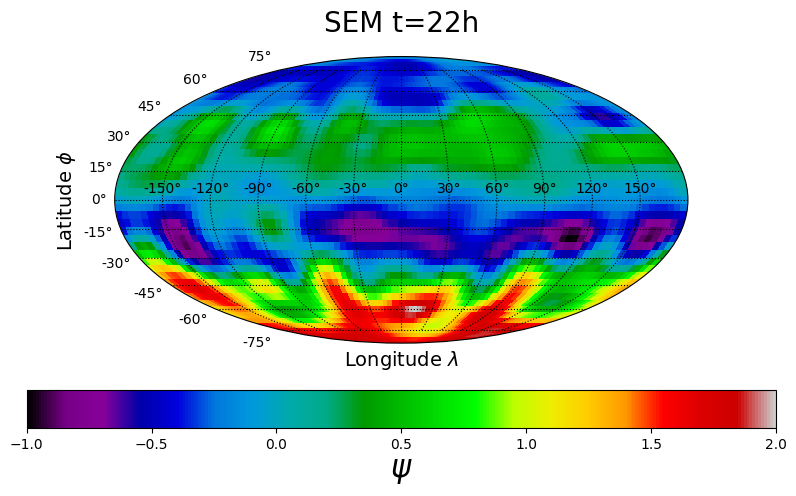

In [31]:
hour_to_plot = 22
time_index = np.where(np.isclose(time_sem_hours, hour_to_plot))[0][0]

psi_plot = psi_sem[time_index]

# Visual-only rescaling to match the paper-like colorbar range.
psi_plot_paper_scale = (
    (psi_plot - psi_plot.min()) / (psi_plot.max() - psi_plot.min())
) * 3.0 - 1.0

plot_global_mollweide(
    field=psi_plot_paper_scale,
    lat_degrees=lat_downsampled,
    lon_degrees=lon_downsampled,
    title="SEM t=22h",
)

In [32]:
np.savez(
    "sem_supervised_dataset.npz",
    supervised_features=supervised_features,
    supervised_targets=supervised_targets,
    supervised_targets_normalized=supervised_targets_normalized,
    supervised_target_mean=supervised_target_mean,
    supervised_target_std=supervised_target_std,
    training_hours=training_hours,
    training_time_normalized=training_time_normalized,
    lat_downsampled=lat_downsampled,
    lon_downsampled=lon_downsampled,
    psi_qcl_training=psi_qcl_training,
    psi_sem=psi_sem,
    zeta_sem=zeta_sem,
    time_sem_hours=time_sem_hours,
    zeta_0=zeta_0,
)